In [47]:
import sys, os
# 将 demos/Strategies 和 ztpy 添加到模块搜索路径
sys.path[:0] = [os.path.abspath('../')]
# ...existing code...

from ztpy import ZtBtEngine,EngineType
from Strategies.DualThrust import StraDualThrust

In [48]:
import os, sys
from pathlib import Path
print("cwd:", os.getcwd())
print("Path.cwd():", Path.cwd())
print("python:", sys.executable)
print("sys.path[:10]:")
for p in sys.path[:10]:
    print("  ", p)

cwd: d:\TempPrjs\wtpy\demos\cta_fut_bt
Path.cwd(): d:\TempPrjs\wtpy\demos\cta_fut_bt
python: d:\TempPrjs\wtpy\.venv\Scripts\python.exe
sys.path[:10]:
   d:\TempPrjs\wtpy\demos
   d:\TempPrjs\wtpy\demos
   d:\TempPrjs\wtpy\demos\Strategies
   d:\TempPrjs\wtpy\demos\cta_fut_bt\demos
   d:\TempPrjs\wtpy\demos\cta_fut_bt\demos
   d:\TempPrjs\wtpy\demos\cta_fut_bt\demos\Strategies
   d:\TempPrjs\wtpy\demos\cta_fut_bt\demos\Strategies
   d:\TempPrjs\wtpy\demos\Strategies
   C:\Program Files\Python313\python313.zip
   C:\Program Files\Python313\DLLs


In [49]:
#创建一个运行环境，并加入策略
engine = ZtBtEngine(EngineType.ET_CTA)
engine.init('../common/', "configbt.yaml")
engine.configBacktest(201909100930,201912011500)
engine.configBTStorage(mode="csv", path="../storage/")
engine.commitBTConfig()

In [50]:
'''
创建DualThrust策略的一个实例
name    策略实例名称
code    回测使用的合约代码
barCnt  要拉取的K线条数
period  要使用的K线周期，m表示分钟线
days    策略算法参数，算法引用的历史数据条数
k1      策略算法参数，上边界系数
k2      策略算法参数，下边界系数
isForStk    DualThrust策略用于控制交易品种的代码
'''
straInfo = StraDualThrust(name='pydt_IF', code="CFFEX.IF.HOT", barCnt=50, period="m5", days=30, k1=0.1, k2=0.1, isForStk=False)
engine.set_cta_strategy(straInfo)

In [51]:
#开始运行回测
engine.run_backtest(bAsync=False)

In [63]:
def analyze_with_pyfolio(fund_filename:str, capital:float=500000):
    import pyfolio as pf
    import pandas as pd
    from datetime import datetime
    import matplotlib.pyplot as plt

    # 读取每日资金
    df = pd.read_csv(fund_filename)
    df['date'] = df['date'].apply(lambda x : datetime.strptime(str(x), '%Y%m%d'))
    df = df.set_index(df["date"])

    # 将资金转换成收益率
    ay = df['dynbalance'] + capital
    rets = ay.pct_change().fillna(0).tz_localize('UTC')

    # 调用pyfolio进行分析
    pf.create_full_tear_sheet(rets)

    # 如果在jupyter，不需要执行该语句
    plt.show()
    

# ...existing code...
def analyze_without_pyfolio(fund_filename: str, capital: float = 500000):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 读取并解析
    df = pd.read_csv(fund_filename, dtype=str)
    df['date'] = pd.to_datetime(df['date'].astype(str).str.strip(), format='%Y%m%d', errors='coerce')
    df = df.set_index('date').sort_index()

    s = df['dynbalance'].astype(str).str.strip().fillna('')
    clean = s.str.replace(',', '', regex=False)
    # 支持百分比或绝对值
    is_pct = clean.str.contains('%', na=False)
    parsed = pd.to_numeric(clean.str.rstrip('%'), errors='coerce')

    vals = pd.Series(index=df.index, dtype='float64')
    if is_pct.any():
        vals.loc[is_pct] = capital * (1.0 + parsed.loc[is_pct].astype(float) / 100.0)
    vals.loc[~is_pct] = parsed.loc[~is_pct].astype(float) + capital

    # 兼容所有 pandas 版本：先前向填充，再用 capital 填剩余空值
    vals = vals.ffill().fillna(capital)

    # 日收益率（若为非日频，请调整 periods_per_year）
    rets = vals.pct_change().dropna()
    days = (vals.index[-1] - vals.index[0]).days or 1
    years = days / 365.25

    total_return = vals.iloc[-1] / vals.iloc[0] - 1
    ann_return = (vals.iloc[-1] / vals.iloc[0]) ** (1.0 / years) - 1 if years > 0 else np.nan
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    # 最大回撤
    cum = vals.cummax()
    drawdown = (vals - cum) / cum
    max_dd = drawdown.min()

    # 年化收益按 calendar
    print(f"Total return: {total_return:.2%}")
    print(f"Annualized return: {ann_return:.2%}")
    print(f"Annualized vol: {ann_vol:.2%}")
    print(f"Sharpe (rf=0): {sharpe:.2f}")
    print(f"Max drawdown: {max_dd:.2%}")

    # 绘图：净值曲线 + 回撤
    plt.figure(figsize=(12,6))
    ax1 = plt.subplot(2,1,1)
    vals.plot(ax=ax1, title="Equity Curve")
    ax1.set_ylabel("Portfolio Value")
    ax2 = plt.subplot(2,1,2, sharex=ax1)
    (drawdown).plot(ax=ax2, color='red', title="Drawdown")
    ax2.set_ylabel("Drawdown")
    plt.tight_layout()
    plt.show()

    # 月度收益热力图（可选）
    monthly = (vals.resample('ME').last().pct_change().dropna())
    if not monthly.empty:
        m = monthly.to_frame('r')
        m['year'] = m.index.year
        m['month'] = m.index.month
        pivot = m.pivot_table(index='year', columns='month', values='r')
        plt.figure(figsize=(9,4))
        sns.heatmap(pivot, fmt=".2%", cmap='RdYlGn', center=0, annot=True)
        plt.title("Monthly returns")
        plt.show()

    return {
        'values': vals,
        'returns': rets,
        'annual_return': ann_return,
        'annual_vol': ann_vol,
        'sharpe': sharpe,
        'max_drawdown': max_dd
    }
# ...existing code...
# ...existing code...

In [53]:
import pandas as pd
fn = "./outputs_bt/pydt_IF/funds.csv"
df = pd.read_csv(fn, dtype=str)
s = df['dynbalance'].astype(str).str.strip().fillna('')
clean = s.str.replace(',', '', regex=False)
has_pct = clean.str.contains('%', na=False).any()
parsed = pd.to_numeric(clean.str.rstrip('%'), errors='coerce')
print("has percent rows:", has_pct)
print("total rows:", len(df), "unparsed rows:", parsed.isna().sum())
if parsed.isna().any():
    print(df.loc[parsed.isna(), ['date','dynbalance']].head(20).to_string(index=False))
else:
    print("all dynbalance parsed OK")

has percent rows: False
total rows: 32 unparsed rows: 0
all dynbalance parsed OK


Total return: -28.86%
Annualized return: -91.27%
Annualized vol: 32.86%
Sharpe (rf=0): -2.78
Max drawdown: -29.24%


C:\Users\SKYlarS\AppData\Local\Temp\ipykernel_15516\3999653478.py:74: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  vals.plot(ax=ax1, title="Equity Curve")
C:\Users\SKYlarS\AppData\Local\Temp\ipykernel_15516\3999653478.py:77: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  (drawdown).plot(ax=ax2, color='red', title="Drawdown")


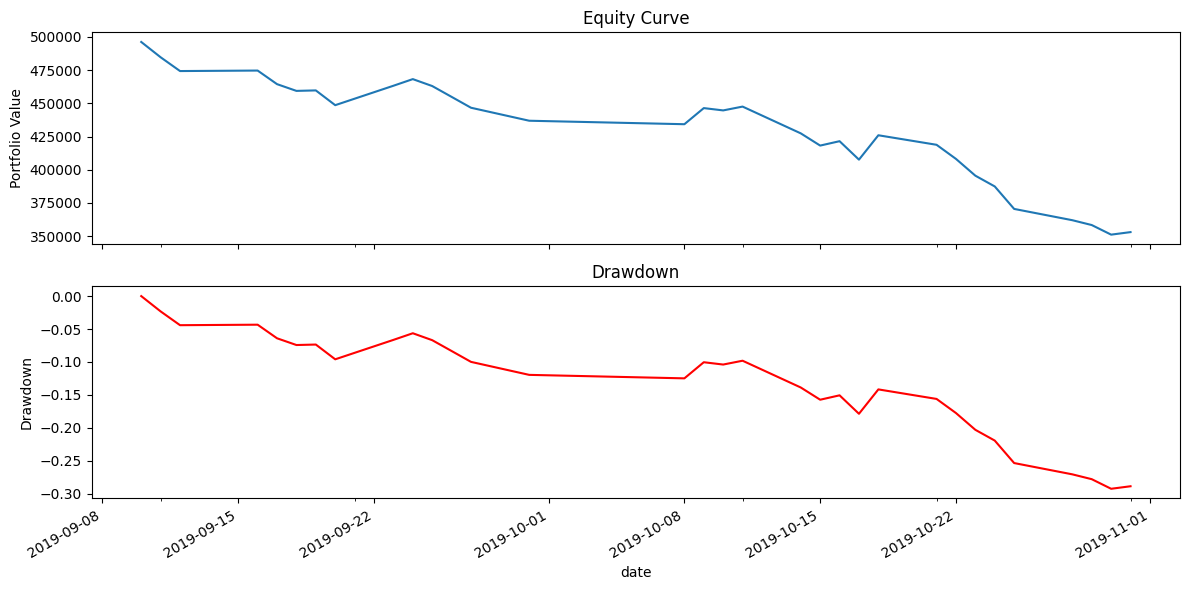

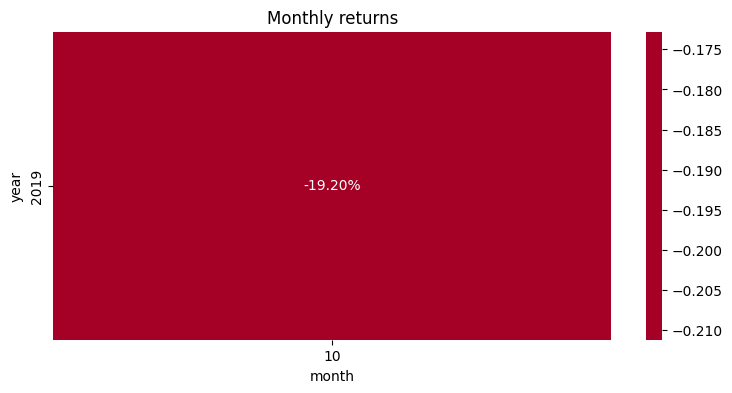

{'values': date
 2019-09-10    496225.95
 2019-09-11    484691.90
 2019-09-12    474318.39
 2019-09-16    474691.89
 2019-09-17    464458.05
 2019-09-18    459380.31
 2019-09-19    459741.98
 2019-09-20    448625.13
 2019-09-23    463248.95
 2019-09-24    468249.60
 2019-09-25    463032.94
 2019-09-26    454872.13
 2019-09-27    446685.69
 2019-09-30    436904.84
 2019-10-08    434281.43
 2019-10-09    446419.48
 2019-10-10    444677.77
 2019-10-11    447557.93
 2019-10-14    427392.79
 2019-10-15    418190.53
 2019-10-16    421495.89
 2019-10-17    407602.35
 2019-10-18    425961.05
 2019-10-21    418783.77
 2019-10-22    408162.53
 2019-10-23    395521.68
 2019-10-24    387416.84
 2019-10-25    370487.16
 2019-10-28    361986.09
 2019-10-29    358342.32
 2019-10-30    351116.39
 2019-10-31    353019.96
 dtype: float64,
 'returns': date
 2019-09-11   -0.023244
 2019-09-12   -0.021402
 2019-09-16    0.000787
 2019-09-17   -0.021559
 2019-09-18   -0.010933
 2019-09-19    0.000787
 2019-

In [64]:
analyze_without_pyfolio("./outputs_bt/pydt_IF/funds.csv",500000)

In [65]:
engine.release_backtest()

OSError: exception: access violation reading 0xFFFFFFFFFFFFFFFF